# TP 1 — PCA et LDA : solution commentée

Solution complète du [TP 1](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

## Exercice 1 — PCA 2D

variance expliquée 2D : 0.221


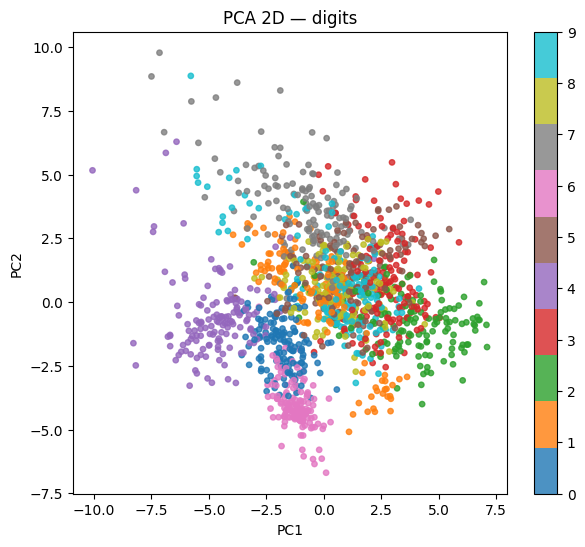

In [2]:
pca2 = PCA(n_components=2).fit(X_train_s)
X_pca = pca2.transform(X_train_s)
print(f"variance expliquée 2D : {pca2.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab10", s=15, alpha=0.8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA 2D — digits")
plt.colorbar(sc, ticks=range(10))

## Exercice 2 — Variance cumulée

90 % variance → 31 composantes ;   95 % variance → 39 composantes


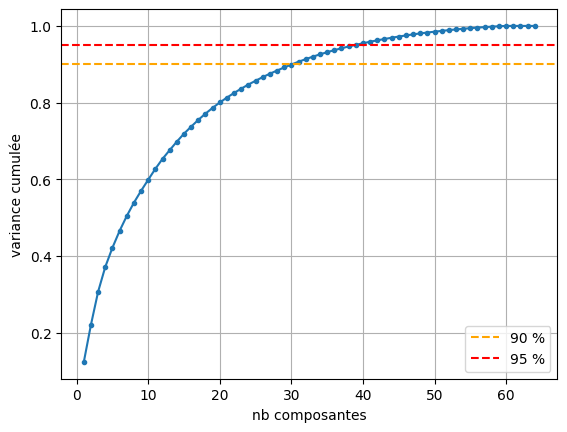

In [3]:
pca_full = PCA().fit(X_train_s)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.searchsorted(cum, 0.90) + 1
n95 = np.searchsorted(cum, 0.95) + 1
print(f"90 % variance → {n90} composantes ;   95 % variance → {n95} composantes")

plt.plot(range(1, len(cum) + 1), cum, marker="o", markersize=3)
plt.axhline(0.90, color="orange", ls="--", label="90 %")
plt.axhline(0.95, color="red", ls="--", label="95 %")
plt.xlabel("nb composantes")
plt.ylabel("variance cumulée")
plt.legend()
plt.grid(True)

## Exercice 3 — LDA 2D

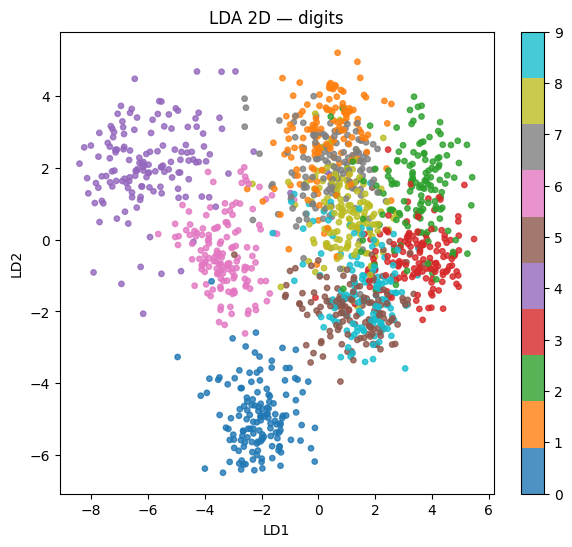

In [4]:
lda = LinearDiscriminantAnalysis(n_components=2).fit(X_train_s, y_train)
X_lda = lda.transform(X_train_s)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X_lda[:, 0], X_lda[:, 1], c=y_train, cmap="tab10", s=15, alpha=0.8)
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_title("LDA 2D — digits")
plt.colorbar(sc, ticks=range(10))

**Discussion** : LDA sépare visiblement mieux les classes parce qu'elle utilise les labels pour orienter ses axes vers la maximisation de la séparation inter-classes. PCA, en cherchant la variance, ne « sait pas » que certaines variations sont entre-classes plutôt qu'intra-classes.

## Exercice 4 — Effet sur la classification

In [5]:
pipes = {
    "A no-PCA": Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
    "B PCA-10": Pipeline(
        [
            ("sc", StandardScaler()),
            ("pca", PCA(n_components=10)),
            ("clf", LogisticRegression(max_iter=2000)),
        ]
    ),
    "C PCA-30": Pipeline(
        [
            ("sc", StandardScaler()),
            ("pca", PCA(n_components=30)),
            ("clf", LogisticRegression(max_iter=2000)),
        ]
    ),
}
for name, p in pipes.items():
    s = cross_val_score(p, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name}: {s.mean():.4f} ± {s.std():.4f}")

A no-PCA: 0.9701 ± 0.0092
B PCA-10: 0.8817 ± 0.0104
C PCA-30: 0.9548 ± 0.0106


**Discussion** : avec 30 composantes (≈ 95 % de la variance) on retrouve presque la performance complète, tout en réduisant de moitié la dimension. À 10 composantes, on perd un peu mais la performance reste raisonnable. La PCA est donc utile pour accélérer l'entraînement sans dégrader fortement la qualité — à condition que les classes restent séparables dans l'espace réduit.